## Geographic comparisons

A side by side comparison of Mississippi regions covering Delta, Gulf Coast, Jackson Metro, Pine Belt, and Other, plus a few statewide rollups for context.

### Importing necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

load_dotenv('../.env')
host = os.getenv('PGHOST', 'localhost')
port = os.getenv('PGPORT', '5432')
db = os.getenv('PGDATABASE', 'ms_health')
user = os.getenv('PGUSER', 'postgres')
pwd = os.getenv('PGPASSWORD', '')
engine = create_engine(f'postgresql+psycopg://{user}:{pwd}@{host}:{port}/{db}')
sns.set(style='whitegrid')

def q(sql):
    return pd.read_sql(text(sql), engine)

### Region detail plus subtotals (using GROUPING SETS)

In [2]:
# GROUPING SETS produces region detail, region subtotals, Delta versus non Delta
# subtotals, and the grand total in a single query. GROUPING() labels each rollup level.
q("""
WITH places_diabetes AS (
    SELECT g.region, g.is_delta, g.total_population, f.data_value AS diabetes_pct
    FROM fact_places f
    JOIN dim_geography g ON g.geo_sk = f.geo_sk
    JOIN dim_measure m ON m.measure_sk = f.measure_sk
    WHERE m.source = 'PLACES' AND m.measure_id = 'DIABETES'
    AND f.year_sk = (SELECT MAX(year_sk) FROM fact_places)
)
SELECT
    COALESCE(region, 'STATEWIDE') AS region,
    CASE WHEN GROUPING(is_delta) = 1 THEN 'all'
        WHEN is_delta THEN 'Delta'
        ELSE 'non-Delta' END AS delta_status,
    COUNT(*) AS tracts,
    SUM(total_population) AS population,
    ROUND((SUM(diabetes_pct * total_population) / NULLIF(SUM(total_population), 0))::NUMERIC, 2) AS pop_weighted_diabetes_pct
FROM places_diabetes
GROUP BY GROUPING SETS ((region, is_delta), (region), (is_delta), ())
ORDER BY GROUPING(region), region NULLS LAST, GROUPING(is_delta), is_delta DESC
""")

,region,delta_status,tracts,population,pop_weighted_diabetes_pct
0,Delta,Delta,153,537726,17.24
1,Delta,all,153,537726,17.24
2,Gulf Coast,non-Delta,139,398440,14.50
3,Gulf Coast,all,139,398440,14.50
4,Jackson Metro,non-Delta,130,492983,14.57
5,Jackson Metro,all,130,492983,14.57
6,Other,non-Delta,383,1290264,16.36
7,Other,all,383,1290264,16.36
8,Pine Belt,non-Delta,65,239328,14.16
9,Pine Belt,all,65,239328,14.16


### What share of women aged 15 to 44 live in a care desert?

In [3]:
# This is the headline statistic for the entire project. We weight by the
# ACS-derived count of women of reproductive age, not raw population, because
# we care about the population at risk of pregnancy. Both dim_geography and
# mart_drive_time expose a `region` column, so qualify with wp.region everywhere.
deserts = q("""
WITH women_pop AS (
    SELECT g.tract_fips, g.region, a.women_reproductive_age
    FROM dim_geography g
    LEFT JOIN acs_headline a ON a.tract_fips = g.tract_fips
)
SELECT wp.region,
    SUM(wp.women_reproductive_age) AS women_15_44,
    SUM(CASE WHEN d.is_care_desert THEN wp.women_reproductive_age ELSE 0 END) AS women_in_care_desert,
    ROUND((100.0 * SUM(CASE WHEN d.is_care_desert THEN wp.women_reproductive_age ELSE 0 END)
        / NULLIF(SUM(wp.women_reproductive_age), 0))::NUMERIC, 1) AS pct_women_in_care_desert
FROM women_pop wp
LEFT JOIN mart_drive_time d ON d.tract_fips = wp.tract_fips
GROUP BY wp.region
ORDER BY pct_women_in_care_desert DESC NULLS LAST
""")
deserts

,region,women_15_44,women_in_care_desert,pct_women_in_care_desert
0,Delta,52235.0,26721.0,51.2
1,Other,131363.0,12063.0,9.2
2,Jackson Metro,50709.0,275.0,0.5
3,Gulf Coast,36629.0,0.0,0.0
4,Pine Belt,27450.0,0.0,0.0


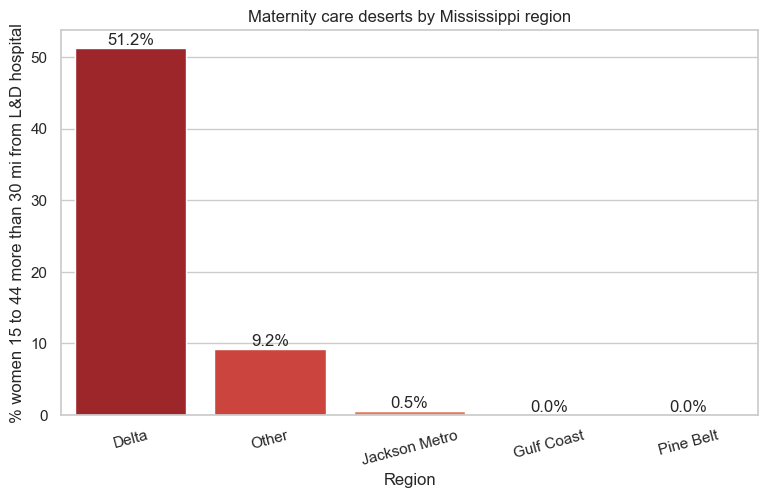

In [4]:
# Bar chart of percent of women aged 15 to 44 in a care desert, per region.
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=deserts, x='region', y='pct_women_in_care_desert',
            hue='region', palette='Reds_r', legend=False, ax=ax)
for i, v in enumerate(deserts['pct_women_in_care_desert']):
    if pd.notna(v):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
ax.set_ylabel('% women 15 to 44 more than 30 mi from L&D hospital')
ax.set_xlabel('Region')
ax.set_title('Maternity care deserts by Mississippi region')
plt.xticks(rotation=15)
plt.show()

### Is the Delta vs Rest diabetes gap statistically significant?

In [5]:
# Mann Whitney U significance test for the Delta versus rest of state diabetes gap.
# Non parametric, so no assumption about the shape of the distribution.
df = q("""
SELECT g.is_delta, f.data_value AS diabetes
FROM fact_places f
JOIN dim_geography g ON g.geo_sk = f.geo_sk
JOIN dim_measure m ON m.measure_sk = f.measure_sk
WHERE m.source='PLACES' AND m.measure_id='DIABETES'
AND f.year_sk = (SELECT MAX(year_sk) FROM fact_places)
""")

stat, p = mannwhitneyu(df.loc[df['is_delta'], 'diabetes'],
                       df.loc[~df['is_delta'], 'diabetes'],
                       alternative='greater')
print(f'Mann Whitney U (Delta > Rest): U={stat:.0f}, p={p:.3e}')

Mann Whitney U (Delta > Rest): U=67634, p=2.945e-06
